In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


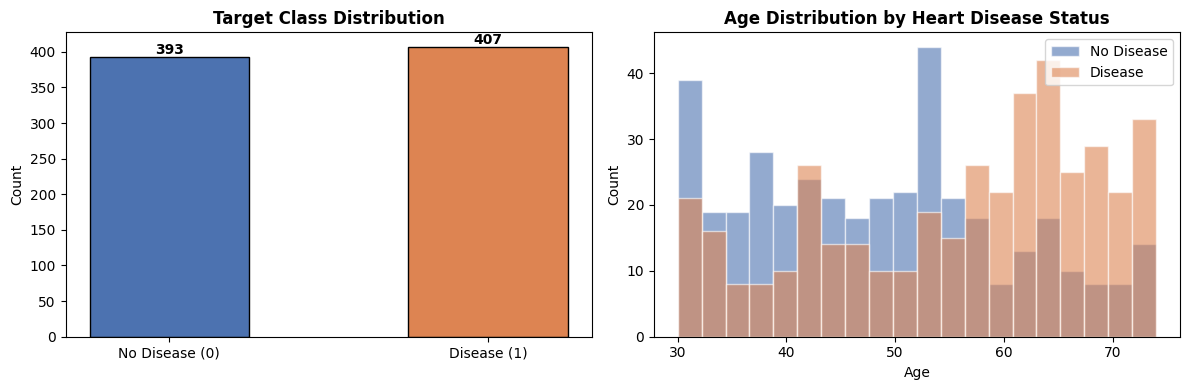

In [11]:
# Plot 1: Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['heart_disease'].value_counts().sort_index()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')

# Plot 2: Age distribution by target
for label, color, lbl in [(0, '#4C72B0', 'No Disease'), (1, '#DD8452', 'Disease')]:
    axes[1].hist(df[df['heart_disease'] == label]['age'], bins=20,
                 alpha=0.6, color=color, label=lbl, edgecolor='white')
axes[1].set_title('Age Distribution by Heart Disease Status', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.show()

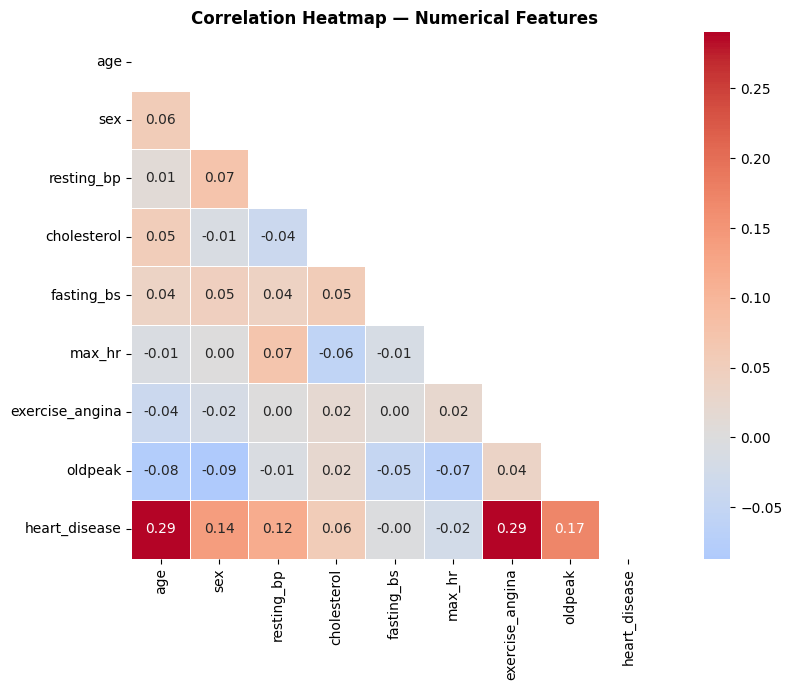

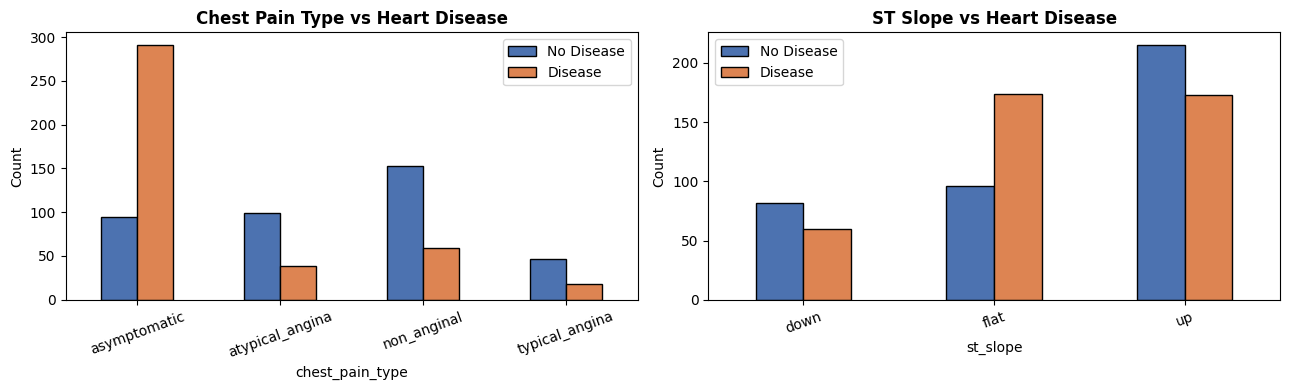

In [12]:
# Plot 3: Correlation heatmap
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 4: Categorical features vs target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [
    (axes[0], 'chest_pain_type', 'Chest Pain Type vs Heart Disease'),
    (axes[1], 'st_slope',        'ST Slope vs Heart Disease'),
]:
    ct = pd.crosstab(df[col], df['heart_disease'])
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black', rot=20)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_proc = df.copy()

# Median imputation
df_proc['resting_bp']  = df_proc['resting_bp'].fillna(df_proc['resting_bp'].median())
df_proc['cholesterol'] = df_proc['cholesterol'].fillna(df_proc['cholesterol'].median())
print("NaN remaining:", df_proc.isnull().sum().sum())

# One-hot encoding
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=False, dtype=int)
print("Shape after encoding:", df_proc.shape)

# Feature/target split
X = df_proc.drop('heart_disease', axis=1)
y = df_proc['heart_disease']

# Train/test split — stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# StandardScaler on numerical features (fit on train only)
num_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train dist: {y_train.value_counts().to_dict()}")
print(f"Test  dist: {y_test.value_counts().to_dict()}")

NaN remaining: 0
Shape after encoding: (800, 19)
Train: (640, 18), Test: (160, 18)
Train dist: {1: 326, 0: 314}
Test  dist: {1: 81, 0: 79}


### Missing Value Strategy Justification — 

Columns affected: `resting_bp` (24 missing, ~3%) and `cholesterol` (32 missing, ~4%)

Strategy chosen: Median Imputation

**Why median?**
- Robust to the outliers common in medical measurements
- Preserves the overall distribution of the column
- Missing percentage is small (3–4%), so median introduces minimal artificial noise
- Simple, interpretable, and widely accepted for numerical medical data

**Conclusion:**
Median imputation is the most suitable strategy here — it retains all 800 rows, handles outliers gracefully, and replaces missing values with the most representative value of each column.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Random Forest':     RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"✔  {name} trained")

✔  Decision Tree trained
✔  Random Forest trained
✔  Gradient Boosting trained


In [15]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)

results = {}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'preds':     y_pred,
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'accuracy':  accuracy_score(y_test, y_pred),
    }
    print(f"{'='*50}\n  {name}\n{'='*50}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"  Precision : {results[name]['precision']:.4f}")
    print(f"  Recall    : {results[name]['recall']:.4f}")
    print(f"  F1-Score  : {results[name]['f1']:.4f}")
    print(f"  Accuracy  : {results[name]['accuracy']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

  Decision Tree
Confusion Matrix:
 [[56 23]
 [22 59]]
  Precision : 0.7195
  Recall    : 0.7284
  F1-Score  : 0.7239
  Accuracy  : 0.7188

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

  Random Forest
Confusion Matrix:
 [[60 19]
 [15 66]]
  Precision : 0.7765
  Recall    : 0.8148
  F1-Score  : 0.7952
  Accuracy  : 0.7875

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

  Gradient Boosting
Co

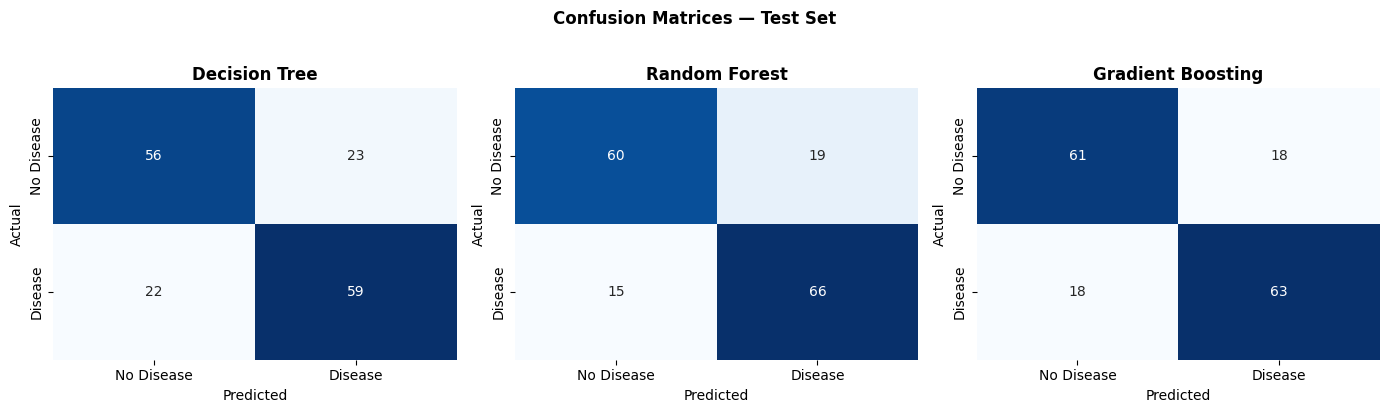

                  precision    recall        f1 accuracy
Decision Tree      0.719512  0.728395  0.723926  0.71875
Random Forest      0.776471  0.814815  0.795181   0.7875
Gradient Boosting  0.777778  0.777778  0.777778    0.775


In [16]:
# Confusion matrix heatmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, trained.keys()):
    cm = confusion_matrix(y_test, results[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'], cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — Test Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
metrics_df = pd.DataFrame(results).T[['precision', 'recall', 'f1', 'accuracy']]
print(metrics_df.round(4).to_string())

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1,
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1-Score (5-fold): {grid_search.best_score_:.4f}")

# Compare tuned vs untuned on test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(f"\n{'Metric':<12} {'Untuned':>10} {'Tuned':>10} {'Delta':>10}")
print("-" * 44)
for metric, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    base  = fn(y_test, results['Random Forest']['preds'])
    tuned = fn(y_test, y_pred_tuned)
    delta = tuned - base
    sign  = '▲' if delta > 0 else '▼'
    print(f"{metric:<12} {base:>10.4f} {tuned:>10.4f}  {sign} {abs(delta):.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1-Score (5-fold): 0.8331

Metric          Untuned      Tuned      Delta
--------------------------------------------
Precision        0.7765     0.7614  ▼ 0.0151
Recall           0.8148     0.8272  ▲ 0.0123
F1               0.7952     0.7929  ▼ 0.0023
